# Pagoda2.1 CITE-seq Workflow (RNA + protein)

This notebook shows the pagoda2.1 **multimodal** workflow on a CITE-seq
sample — 10x Genomics [PBMC 1k protein
v3](https://www.10xgenomics.com/datasets/1-k-pbm-cs-using-3-prime-feature-barcoding-3-standard-3-0-0)
— where each cell is measured by both RNA and a panel of surface-protein
antibodies (ADT). The public 10x file is
`pbmc_1k_protein_v3_filtered_feature_bc_matrix.h5`; here it is in a
local folder named `data`.

In pagoda2.1 each modality is a **facet**: its own raw counts + a
normalization *view recipe*. RNA uses the `plain` model
(depth-normalize + log1p); CITE-seq protein uses `clr` (centered
log-ratio across proteins per cell). A multimodal 10x HDF5 is imported
into facets automatically from its `feature_type` column. The pipeline
steps are generic — the algorithm is a `method=` — and integration
across facets is just `runGraph(method = "wnn")`.

## Import into facets

In [ ]:
h5 <- "data/pbmc_1k_protein_v3_filtered_feature_bc_matrix.h5"
p2 <- suppressMessages(pagoda2::Pagoda2$from10xH5(h5, verbose = FALSE))

do.call(rbind, lapply(p2$listFacets(), function(f) {
  x <- p2$getFacet(f)
  data.frame(facet = f, model = x$modelType, feature_type = x$featureType,
             features = ncol(x$rawCounts), cells = nrow(x$rawCounts),
             default_reduction = x$defaultReduction)
}))

  facet model feature_type features cells default_reduction
1   RNA plain         gene    33538   713               PCA
2   ADT   clr      protein       17   713               PCA

`Gene Expression` became the RNA facet (`plain`) and `Antibody Capture`
became the ADT facet (`clr`). Both share the same cells.

## QC

In [ ]:
suppressMessages(invisible(p2$runQC(verbose = FALSE)))
qc <- p2$resolveCellMeta(c("n_molecules", "n_genes", "qc_pass"))
data.frame(cells = nrow(qc),
           qc_pass = sum(as.logical(qc$qc_pass), na.rm = TRUE),
           median_molecules = median(qc$n_molecules, na.rm = TRUE),
           median_genes = median(qc$n_genes, na.rm = TRUE))

  cells qc_pass median_molecules median_genes
1   713     693             6416         1930

## Per-facet reductions

Each facet is normalized and reduced on its own: RNA → PCA on
overdispersed genes; ADT → PCA on the CLR view of the (few) proteins.
Scores are stored under name-keyed reductions (`PCA` for the default RNA
facet, `ADT:PCA` for the ADT facet).

In [ ]:
suppressWarnings({
  p2$runVariance(verbose = FALSE)
  p2$runReduction(nPcs = 25, verbose = FALSE)                                   # RNA -> reductions[["PCA"]]
  p2$runVariance(facet = "ADT", use.raw.variance = TRUE, verbose = FALSE)
  p2$runReduction(facet = "ADT", nPcs = 15, verbose = FALSE)                    # ADT -> reductions[["ADT:PCA"]]
})
names(p2$reductions)

[1] "PCA"     "ADT:PCA"

## WNN integration

`runGraph(method = "wnn")` builds a weighted-nearest-neighbor graph: for
each cell it learns a per-modality weight from how well each modality’s
own neighbors predict that cell, then fuses the per-modality graphs. The
per-cell weights land in `cellMeta`, the fused graph in
`graphs[["WNN"]]`, and a joint embedding-ready reduction in
`reductions[["WNN"]]`.

In [ ]:
suppressWarnings(p2$runGraph(method = "wnn", facets = c("RNA", "ADT"), verbose = FALSE))
data.frame(mean_RNA_weight = round(mean(p2$cellMeta$wnn_weight_RNA, na.rm = TRUE), 3),
           mean_ADT_weight = round(mean(p2$cellMeta$wnn_weight_ADT, na.rm = TRUE), 3))

  mean_RNA_weight mean_ADT_weight
1           0.451           0.549

## Joint clustering and embedding

Cluster on the fused WNN graph and embed the joint reduction — the same
generic steps, pointed at the WNN products.

In [ ]:
suppressWarnings({
  p2$runClustering(graph = "WNN", name = "wnn_leiden")
  p2$runEmbedding(reduction = "WNN", name = "umap", verbose = FALSE)
})
data.frame(clusters = length(unique(stats::na.omit(p2$cellMeta$wnn_leiden))))

  clusters
1        8

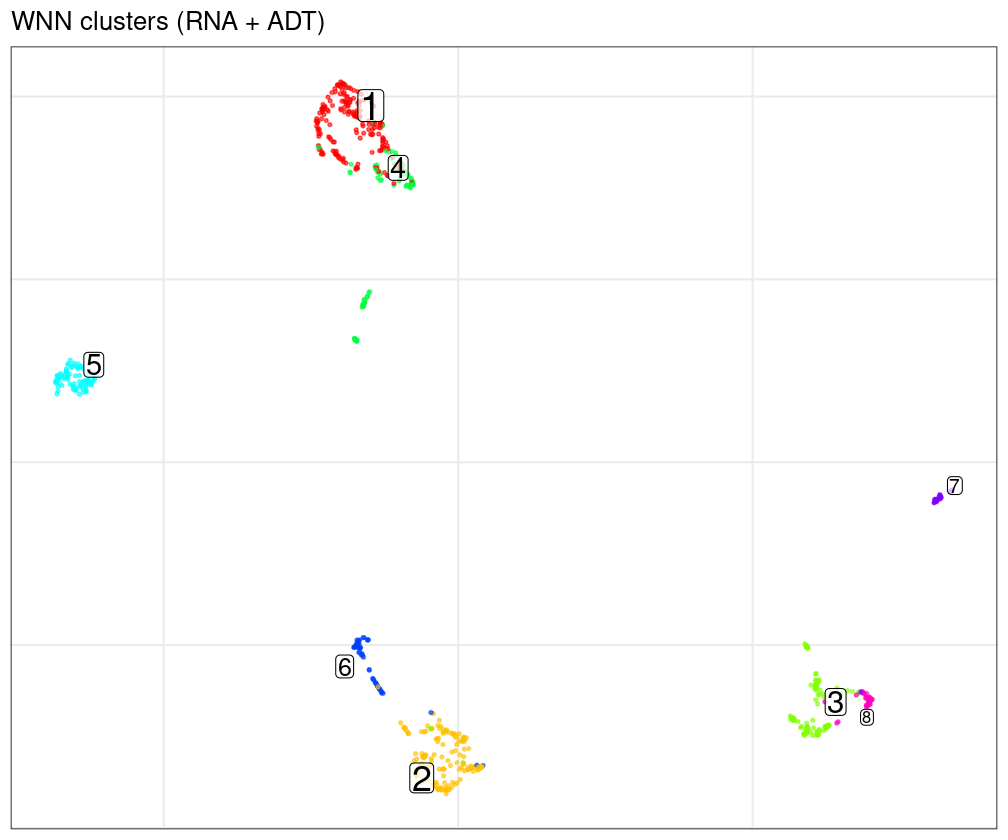

In [ ]:
p2$plotEmbedding(reduction = "WNN", embedding = "umap", grouping = "wnn_leiden",
                 mark.groups = TRUE, size = 0.6, alpha = 0.6, title = "WNN clusters (RNA + ADT)")

The per-cell ADT weight shows where protein information drives the joint
structure: cells in protein-distinguished populations (e.g. T-cell
subsets) lean on ADT, others on RNA.

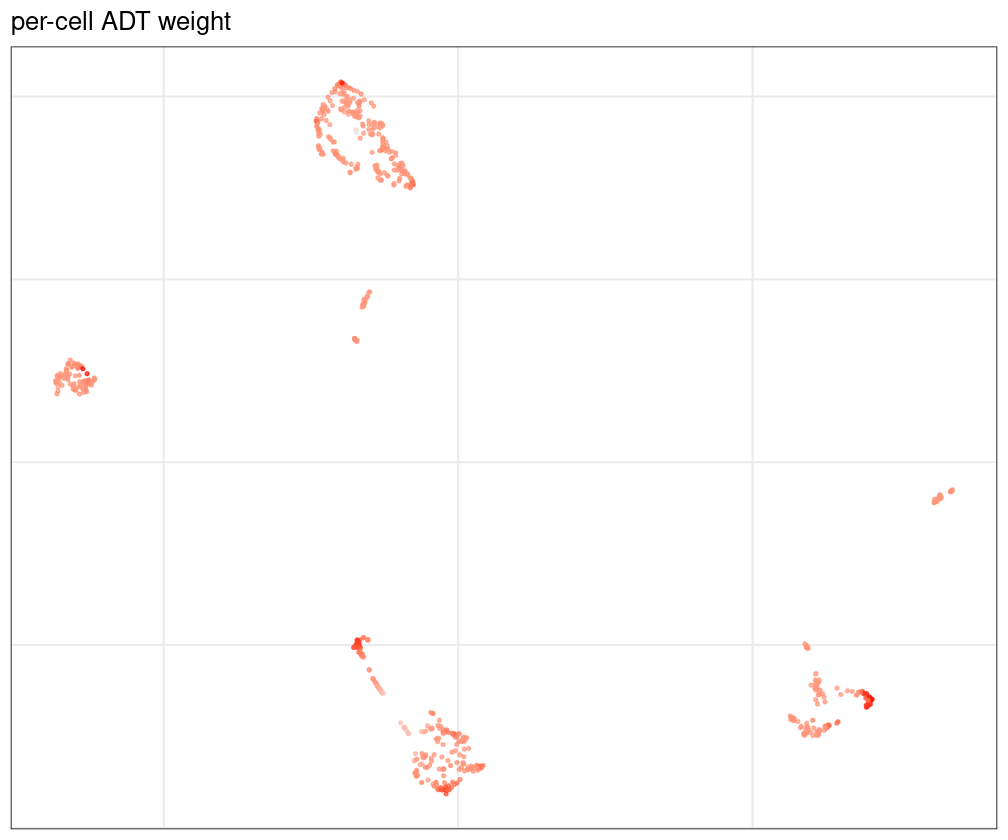

In [ ]:
p2$plotEmbedding(reduction = "WNN", embedding = "umap",
                 colors = stats::setNames(p2$cellMeta$wnn_weight_ADT, rownames(p2$cellMeta)),
                 size = 0.6, alpha = 0.7, title = "per-cell ADT weight")

## Surface proteins on the joint embedding

Color the WNN embedding by a surface protein — the same
`plotEmbedding(gene = ..., facet = "ADT")` call used for RNA, pointed at
the ADT facet. CD3 marks T cells, CD19 marks B cells: the protein
cleanly lights up the joint clusters.

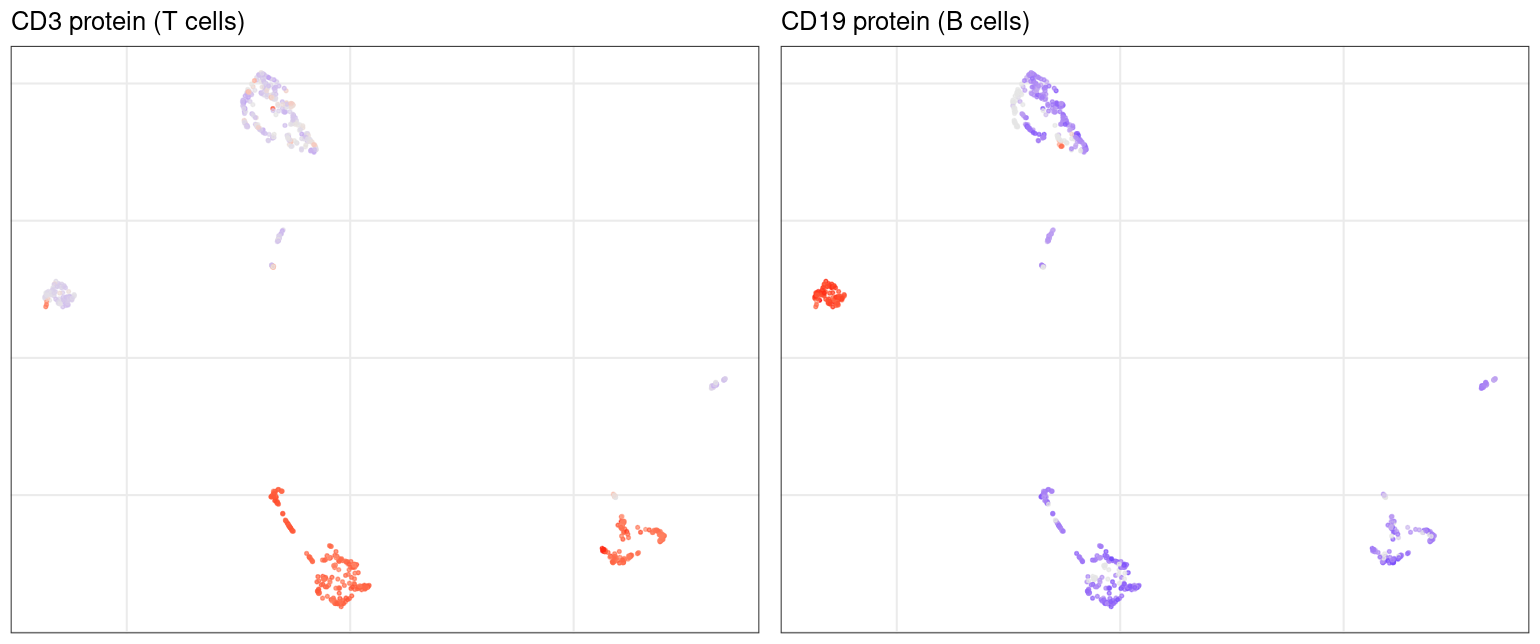

In [ ]:
g_cd3 <- p2$plotEmbedding(reduction = "WNN", embedding = "umap", gene = "CD3_TotalSeqB",
                          facet = "ADT", size = 0.6, alpha = 0.7, title = "CD3 protein (T cells)")
g_cd19 <- p2$plotEmbedding(reduction = "WNN", embedding = "umap", gene = "CD19_TotalSeqB",
                           facet = "ADT", size = 0.6, alpha = 0.7, title = "CD19 protein (B cells)")
cowplot::plot_grid(g_cd3, g_cd19, ncol = 2)

## Markers — RNA and protein

Markers are computed per facet (`facet = "ADT"` stores results
facet-keyed) and the marker plots take the same `facet=` argument,
drawing each facet’s own expression.

In [ ]:
suppressWarnings({
  p2$runMarkers(grouping = "wnn_leiden", name = "wnn_markers", verbose = FALSE)               # RNA
  p2$runMarkers(grouping = "wnn_leiden", facet = "ADT", name = "wnn_markers", verbose = FALSE) # protein
})

RNA markers by WNN cluster (vertical gene labels keep the axis legible
at this many markers):

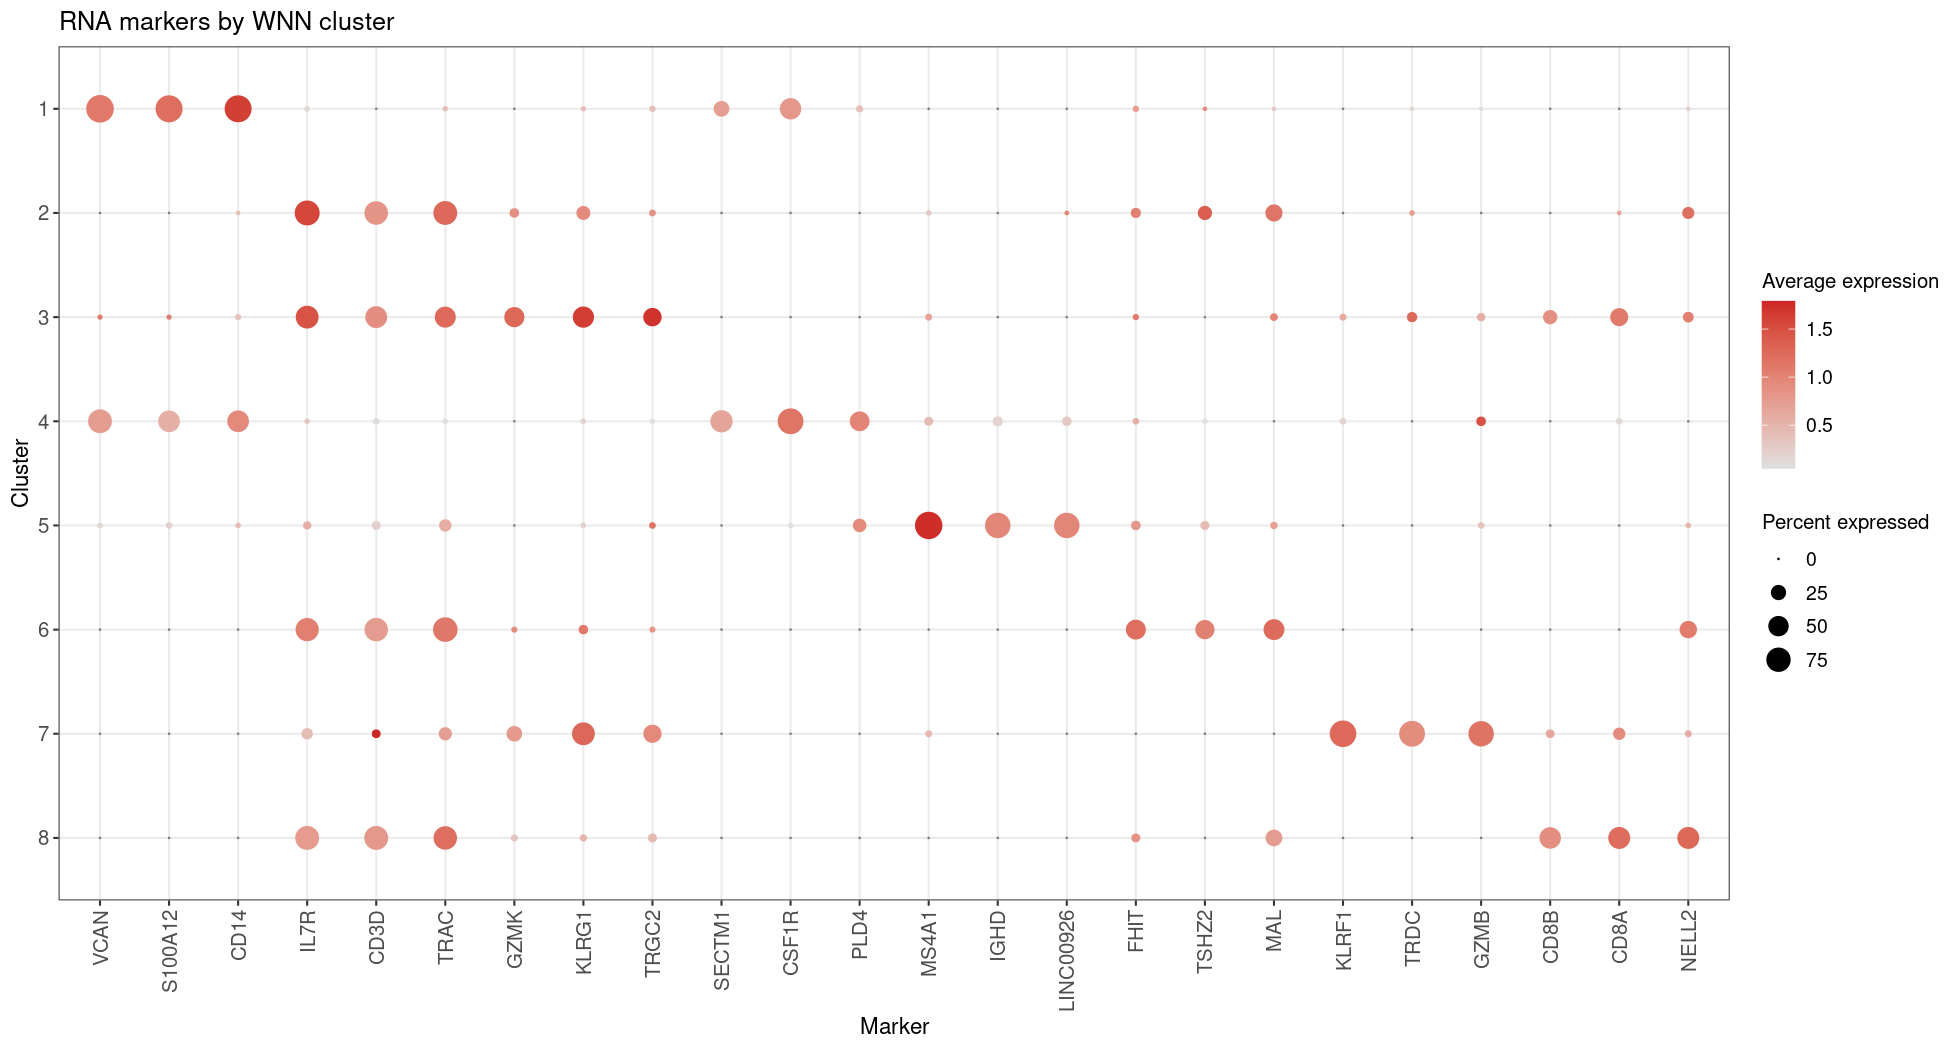

In [ ]:
p2$plotMarkerDotPlot(markers = "wnn_markers", n.genes.per.group = 3, selection = "balanced",
                     order.groups = TRUE, dot.scale = 6) +
  ggplot2::labs(title = "RNA markers by WNN cluster") +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 1, vjust = 0.5))

Surface proteins are detected in nearly every cell (CLR), so a dot
plot’s size dimension isn’t useful — the clearest protein view is the
mean CLR per protein across clusters.
`getExpressionBlock(facet = "ADT")` returns the CLR-normalized protein
matrix; surface markers (CD3/CD4/CD8/CD19/CD14/…) cleanly partition the
joint clusters.

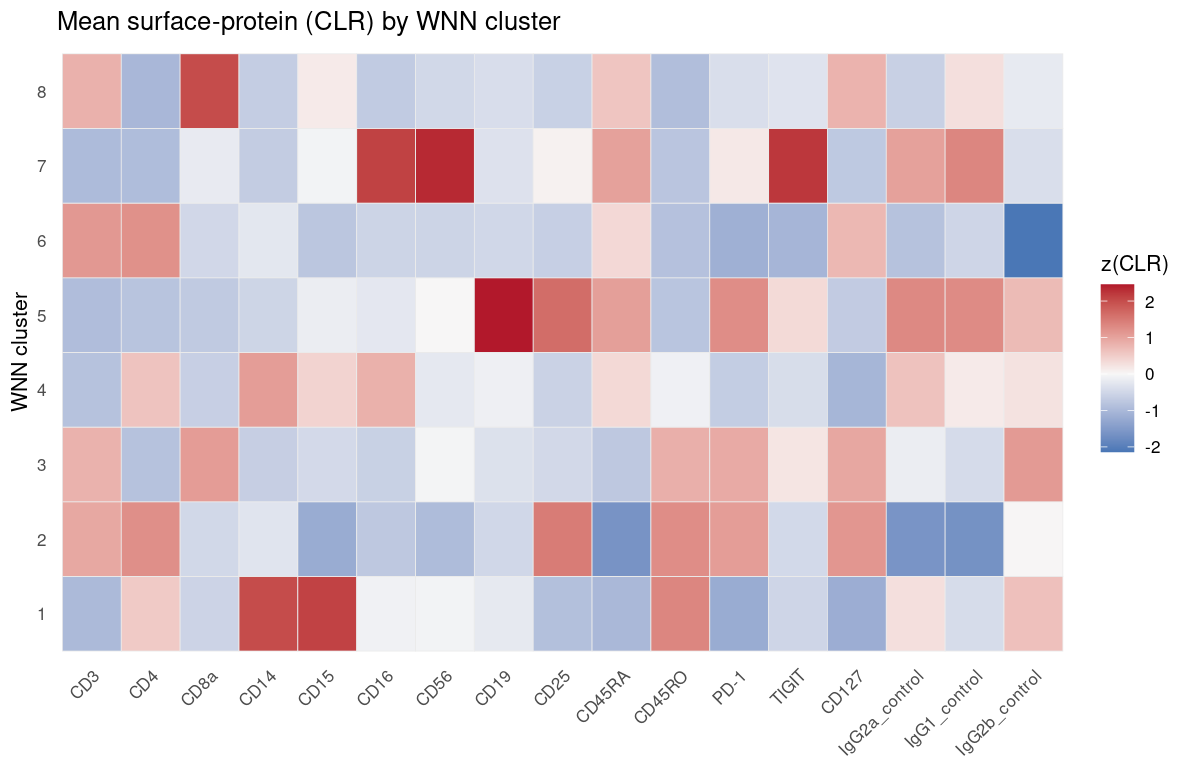

In [ ]:
adt <- as.matrix(p2$getExpressionBlock(facet = "ADT"))                       # cells x proteins (CLR)
cl <- p2$cellMeta[rownames(adt), "wnn_leiden"]
prot_by_cluster <- t(sapply(split(seq_len(nrow(adt)), cl),
                            function(i) colMeans(adt[i, , drop = FALSE])))    # clusters x proteins
colnames(prot_by_cluster) <- sub("_TotalSeqB$", "", colnames(prot_by_cluster))
zs <- scale(prot_by_cluster)                                                 # z-score per protein
df <- data.frame(cluster = factor(rownames(zs)[row(zs)], levels = rownames(zs)),
                 protein = factor(colnames(zs)[col(zs)], levels = colnames(zs)),
                 z = as.numeric(zs))
ggplot2::ggplot(df, ggplot2::aes(protein, cluster, fill = z)) +
  ggplot2::geom_tile(color = "grey92") +
  ggplot2::scale_fill_gradient2(low = "#2166ac", mid = "grey97", high = "#b2182b", name = "z(CLR)") +
  ggplot2::theme_minimal(base_size = 11) +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 45, hjust = 1),
                 panel.grid = ggplot2::element_blank()) +
  ggplot2::labs(title = "Mean surface-protein (CLR) by WNN cluster", x = NULL, y = "WNN cluster")

## Next steps

- **Annotate** the WNN clusters from the joint RNA + protein evidence
  (`p2$annotateClusters(from = "wnn_leiden", ...)`), then the generic
  plots use the annotation by default.
- **Other integrations:** reduction-level joints are also available —
  `p2$runReduction(facets = c("RNA","ADT"), method = "cca")` (or
  `"scca"`, `"concat"`) — stored as `reductions[["CCA"]]` with per-facet
  loadings.
- **Protein markers** are computed facet-keyed via
  `p2$runMarkers(grouping = "wnn_leiden", facet = "ADT")` (stored under
  `markerResults$ADT`).
- See the [single-dataset](pagoda2.1-single-dataset.ipynb) notebook for
  the RNA-only workflow and the [ATAC /
  multiome](pagoda2.1-multiome.ipynb) notebook for RNA + chromatin
  accessibility.